##### ARTI 560 - Computer Vision

## Instance Segmentation - Exercise 

### Objective

In this exercise, you will implement **Instance Object Segmentation** using a pretrained **Mask R-CNN model** from TensorFlow Hub.

You will follow these steps:

1. **Load the pretrained Mask R-CNN model**  
   - Use this Kaggle link: [Mask R-CNN Inception-ResNet-v2](https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2)  

2. **Select and load 5 different images**  
   - Choose **5 diverse images**, including:  
      - Crowded scenes with multiple objects  
      - Unusual angles, lighting conditions, or occlusions  
      - At least **one image containing multiple objects of the same class** 

3. **Perform inference using the model**  
   - Feed images to the model to obtain predictions  

4. **Extract prediction outputs**  
   - **Bounding boxes** – coordinates of detected objects  
   - **Class labels** – names of detected objects  
   - **Segmentation masks** – pixel-wise masks for each object  

5. **Visualize the results**  
   - Overlay masks on detected objects  
   - Draw bounding boxes around objects  
   - Display class names and confidence scores  

6. **Experiment with confidence thresholds**  
   - Default threshold: **0.5**  
   - Lower threshold: **0.3** to detect more objects (may include false positives)  

---

- Keep in mind:  
  - Some objects may not be recognized at the default threshold 
  - The model only detects objects from the **COCO dataset (80 classes)**  


In [7]:
import kagglehub
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

In [2]:
model_path = kagglehub.model_download(
    "tensorflow/mask-rcnn-inception-resnet-v2/TensorFlow2/1024x1024"
)

model = tf.saved_model.load(model_path)
print("Model loaded successfully.")

Model loaded successfully.


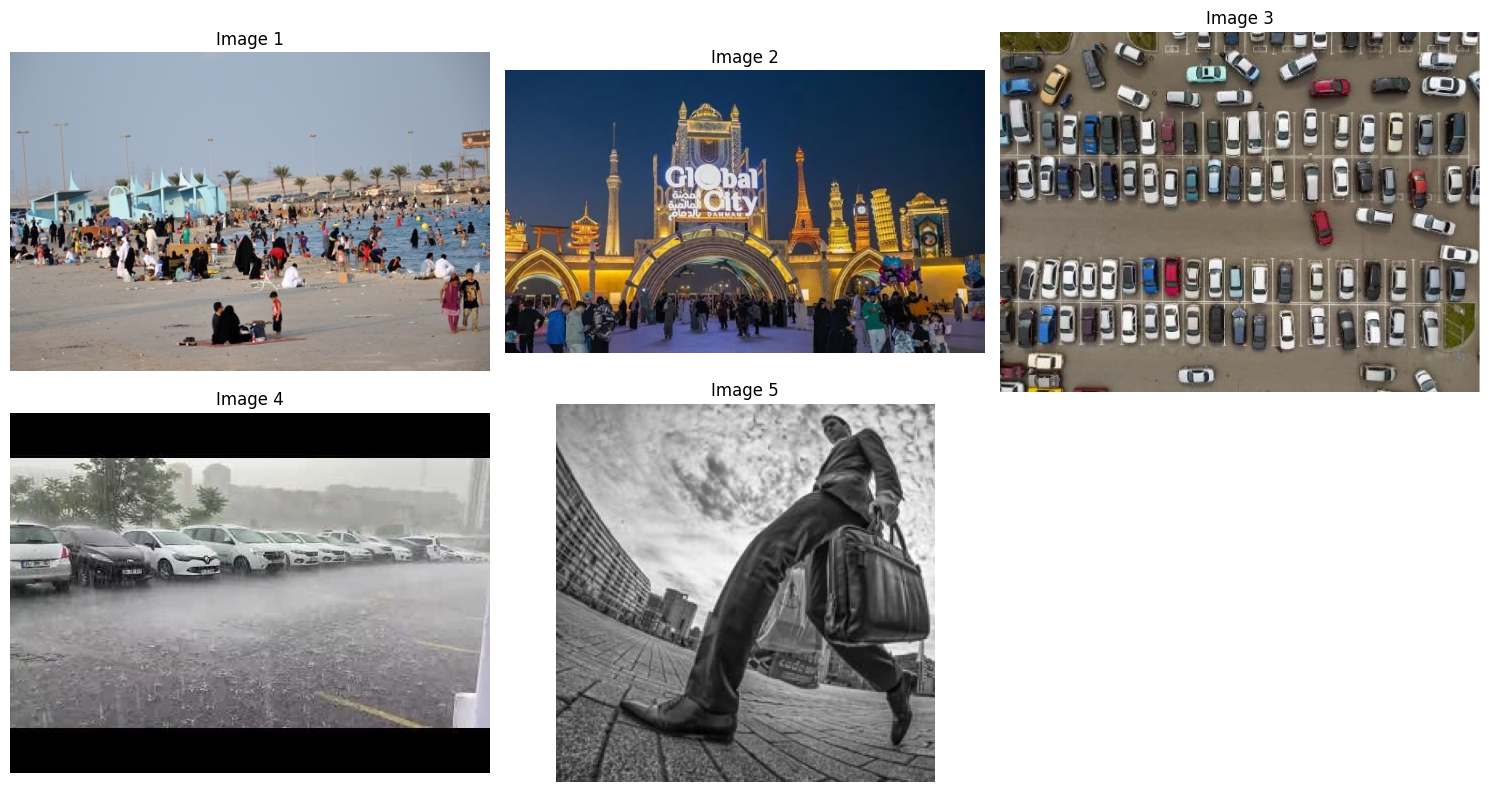

In [ ]:
# Image paths
image_paths = [
    "Images/Beach.jpg",
    "Images/Crowded_place.jpg",
    "Images/Parking.jpg",
    "Images/Rainy_weather.jpg",
    "Images/Unusual_Angle.jpg"
]

# Load images
images = [cv2.imread(path) for path in image_paths]

# Filter out None values in case an image failed to load
images = [img for img in images if img is not None]

# Convert BGR
images_rgb = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for img in images]

# Display images
plt.figure(figsize=(15, 8))
for i, img in enumerate(images_rgb):
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
# Run inference on all images
outputs = []

for img in images_rgb:
    # Convert to tensor
    input_tensor = tf.convert_to_tensor(img, dtype=tf.uint8)
    input_tensor = input_tensor[tf.newaxis, ...]  # add batch dimension

    # Run model
    output = model(input_tensor)

    outputs.append(output)

print("Inference completed on all images.")

Inference completed on all images.


In [5]:
# Extract prediction outputs
boxes_list = []
classes_list = []
scores_list = []
masks_list = []

for output in outputs:
    # Convert tensors to numpy
    boxes = output['detection_boxes'][0].numpy()
    classes = output['detection_classes'][0].numpy().astype(int)
    scores = output['detection_scores'][0].numpy()
    masks = output['detection_masks'][0].numpy()

    boxes_list.append(boxes)
    classes_list.append(classes)
    scores_list.append(scores)
    masks_list.append(masks)

print("Outputs extracted successfully.")

Outputs extracted successfully.



=== Results with threshold = 0.5 ===


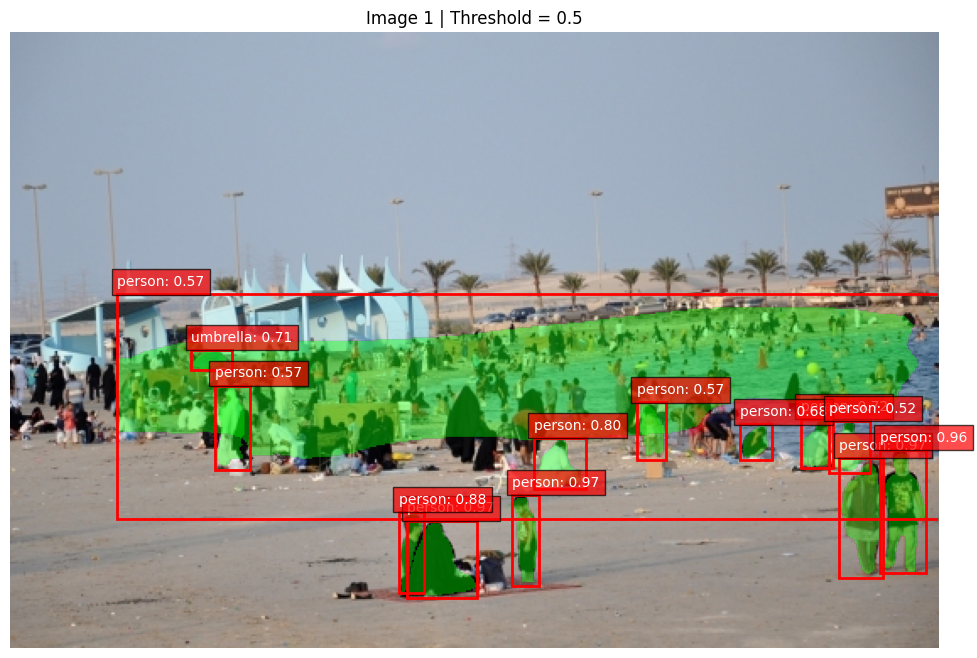

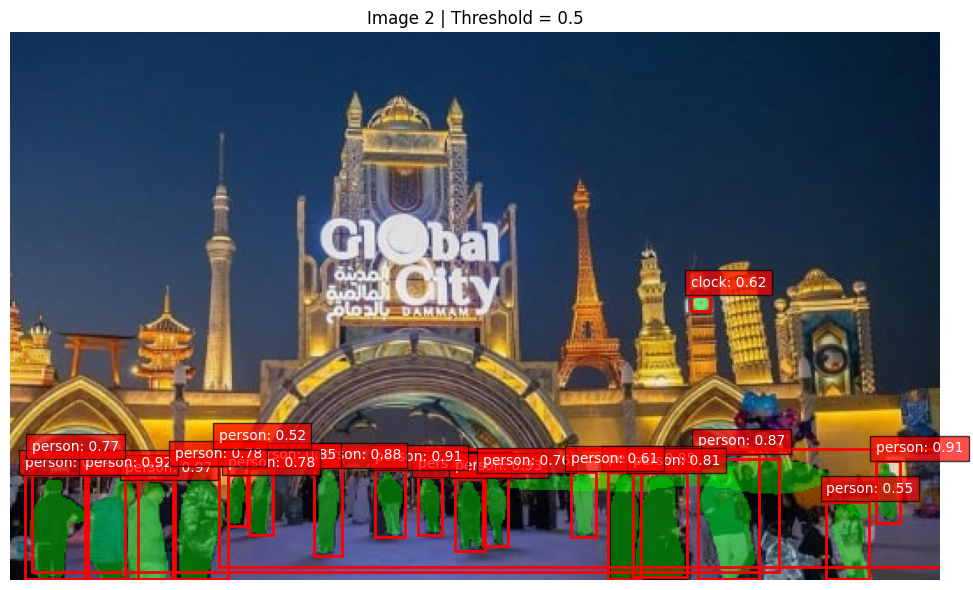

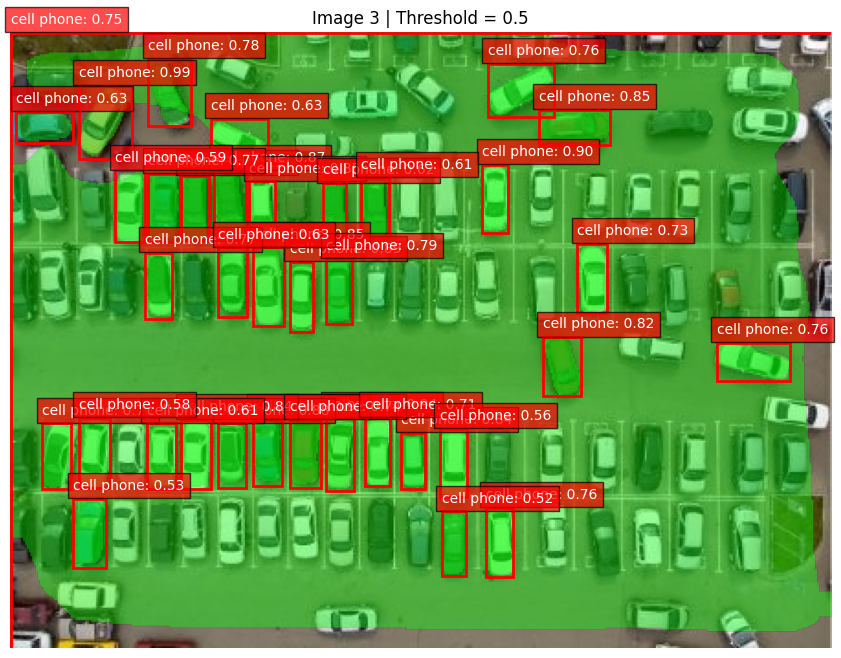

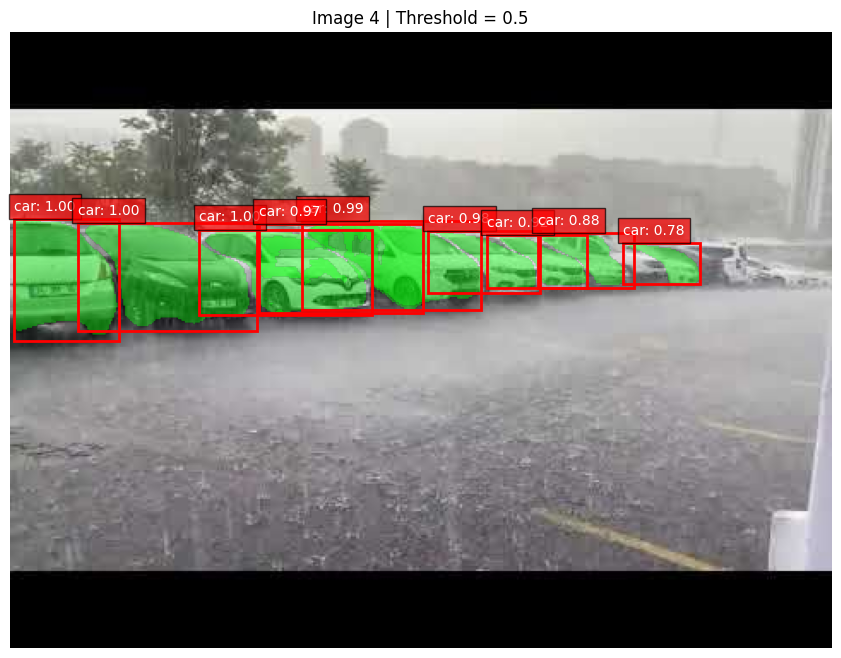

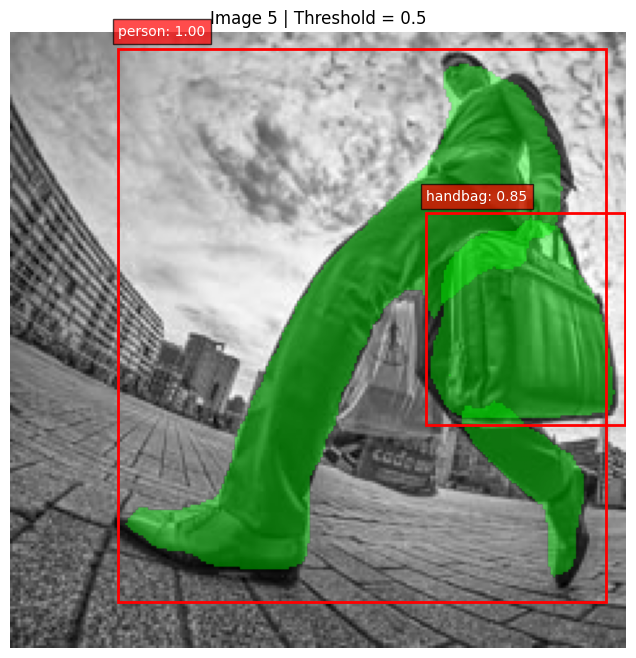


=== Results with threshold = 0.3 ===


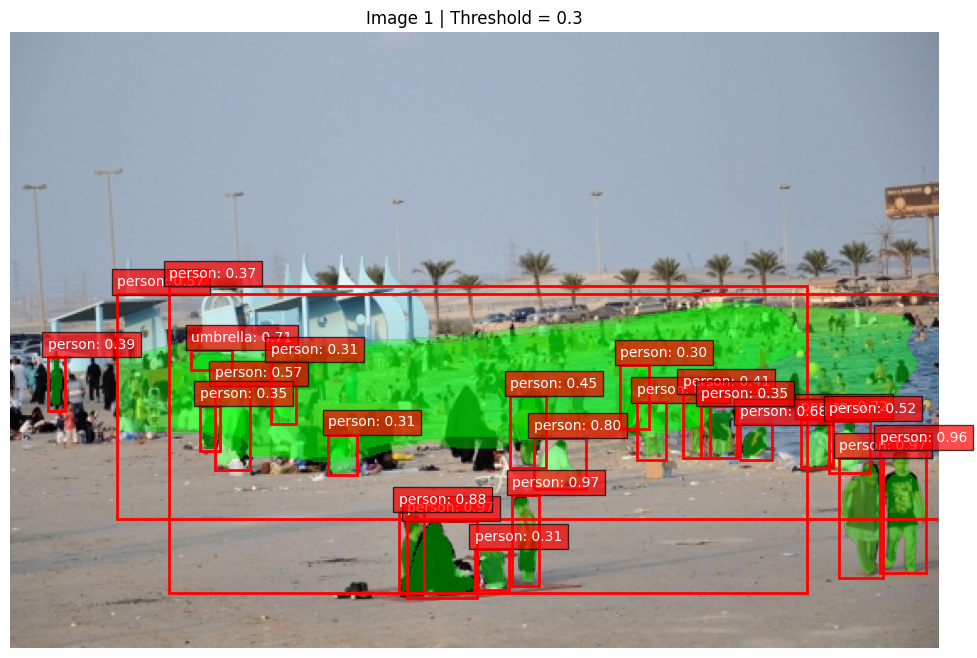

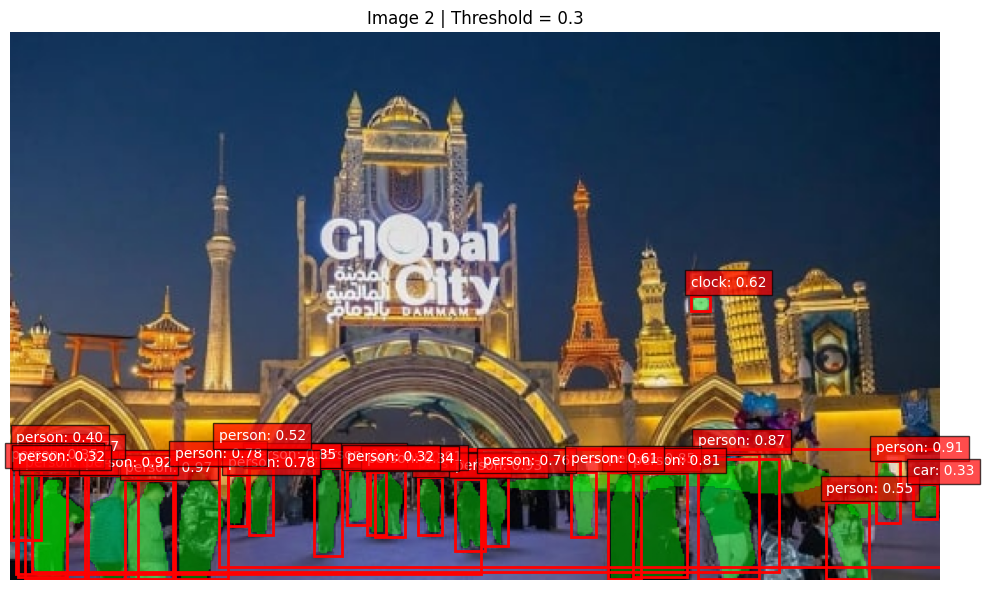

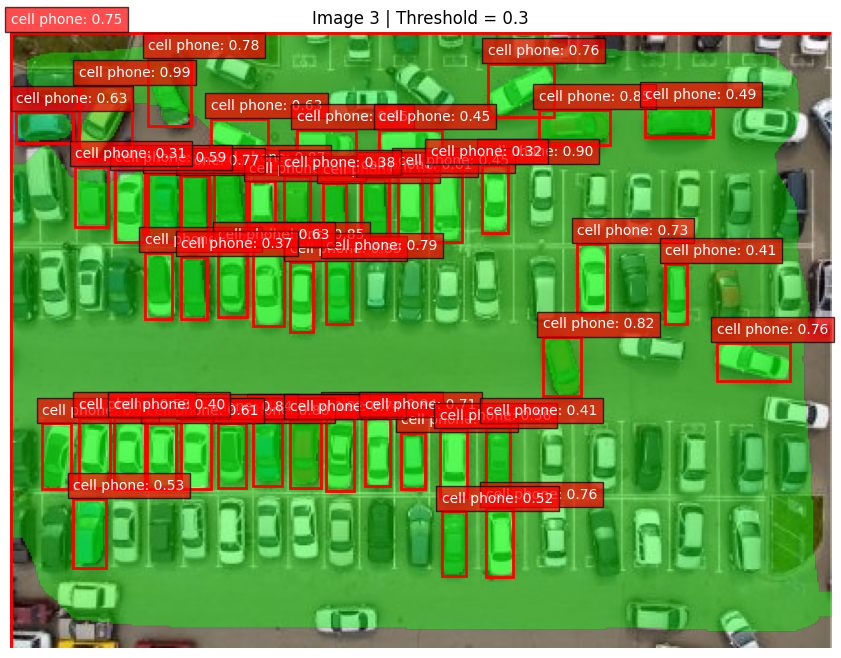

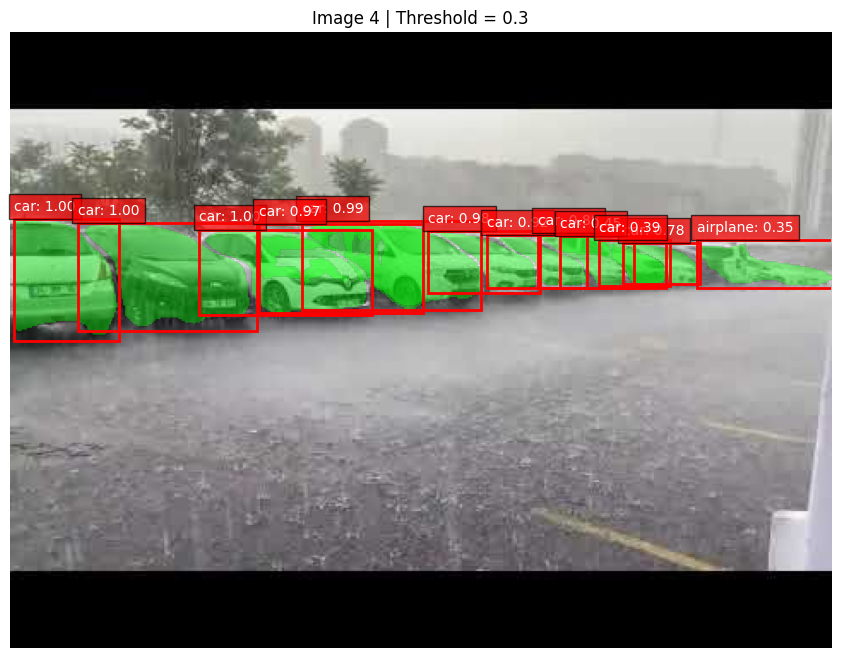

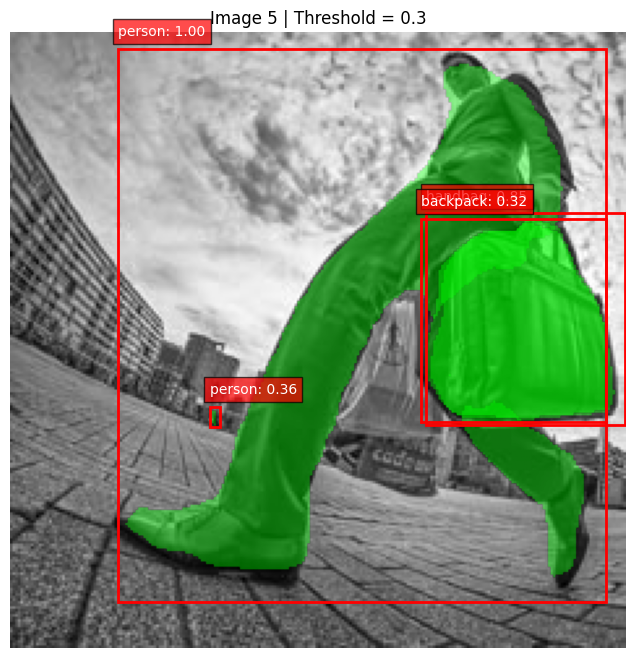

In [10]:
thresholds = [0.5, 0.3]

for threshold in thresholds:
    print(f"\n=== Results with threshold = {threshold} ===")

    for i, img in enumerate(images_rgb):
        fig, ax = plt.subplots(1, figsize=(12, 8))
        ax.imshow(img)

        h, w, _ = img.shape

        boxes = boxes_list[i]
        classes = classes_list[i]
        scores = scores_list[i]
        masks = masks_list[i]

        for j in range(len(scores)):
            if scores[j] < threshold:
                continue

            ymin, xmin, ymax, xmax = boxes[j]
            x1, y1 = int(xmin * w), int(ymin * h)
            x2, y2 = int(xmax * w), int(ymax * h)

            if x2 <= x1 or y2 <= y1:
                continue

            # Bounding box
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)

            # Label
            label = f"{class_names.get(classes[j], 'N/A')}: {scores[j]:.2f}"
            ax.text(x1, y1 - 5, label, color='white', fontsize=10,
                    bbox=dict(facecolor='red', alpha=0.7))

            # Mask
            mask = masks[j]
            mask = cv2.resize(mask, (x2 - x1, y2 - y1))
            mask = mask > 0.5

            mask_resized = np.zeros((h, w), dtype=bool)
            mask_resized[y1:y2, x1:x2] = mask

            colored_mask = np.zeros((h, w, 4))
            colored_mask[mask_resized] = [0, 1, 0, 0.4]
            ax.imshow(colored_mask)

        ax.axis("off")
        ax.set_title(f"Image {i+1} | Threshold = {threshold}")
        plt.show()